In [1]:
!pip install -q -U bitsandbytes==0.49.0
!pip install -q -U peft==0.18.0
!pip install -q -U trl==0.26.2
!pip install -q -U accelerate
!pip install -q -U datasets==4.4.2
!pip install -q -U transformers==4.57.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 20.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.1 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import transformers
import torch
from google.colab import userdata
from datasets import load_dataset
from trl import SFTTrainer
from peft import LoraConfig
from transformers import AutoTokenizer, AutoModelForCausalLM # for generating some text based on decoder based transformer
from transformers import BitsAndBytesConfig, GemmaTokenizer


bitsandbytes for Quntization process.

peft for performance efficient parameter fine tuning.

TRL for supervised finetuning models.

Datasets for the datasetes from the HugginFace

In [4]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

TimeoutException: Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
model_id = "google/gemma-2b"
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype = torch.bfloat16
)

Convert entire datat to 4 bit in the quntization process.
All the finetuninig is done by bfloat16


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_id, tokens = os.environ["HF_TOKEN"])
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config = bnb_config,
    device_map = {"":0},
    token = os.environ["HF_TOKEN"]
)

KeyError: 'HF_TOKEN'

In [ ]:
text = "Quote: Imegination is more,"
device = "cuda:0"
inputs = tokenizer(text, return_tensors = "pt").to(device)

outputs =  model.generate(**inputs, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokkens=True))

In [ ]:
lora_config = LoraConfig(
    r = 8,
    target_modules = ["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"], # Target modules to apply LORA
    task_type = "CAUSAL_LM"
)

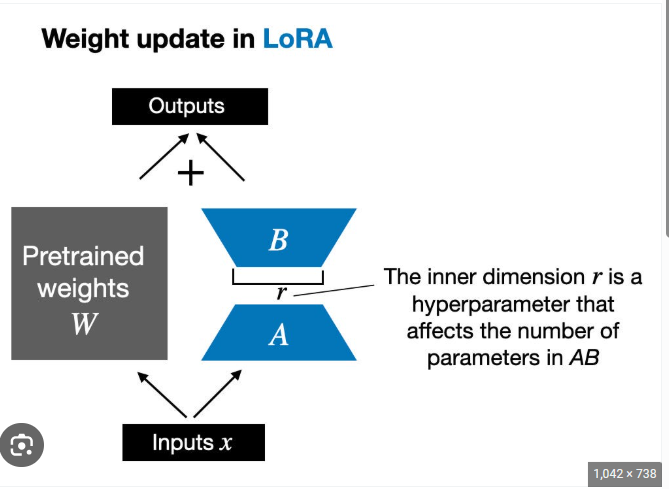

n LoRA (Low-Rank Adaptation) configuration, target_modules specifies which layers (like attention or MLP layers) within a large language model (LLM) get small, trainable adapter matrices, instead of the whole model, making fine-tuning efficient by focusing on key components such as "q_proj" (query), "v_proj" (value), and MLP layers ("gate_proj", etc.) to improve performance and reduce memory.
go through this also : https://blog.stackademic.com/fine-tuning-with-lora-and-qlora-enhancing-efficiency-in-neural-network-adaptation-8b4d1473274b
